# Stage 8: Model Interpretation & Explainability

Using SHAP (SHapley Additive exPlanations) for global and local explanations.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

X_test = pd.read_csv('./data/processed/X_test.csv')
y_test = pd.read_csv('./data/processed/y_test.csv').squeeze()

best_rf  = joblib.load('./models/random_forest.pkl')
best_xgb = joblib.load('./models/xgboost.pkl')

shap.initjs()
print('Libraries loaded ✓')

Libraries loaded ✓


## 8.1 SHAP — Random Forest (TreeExplainer)

In [2]:
# SHAP explainer for RF
rf_explainer = shap.TreeExplainer(best_rf)
rf_shap_values = rf_explainer.shap_values(X_test)

# For binary classification, shap_values is a list [class0, class1]
# Use class 1 (Potable)
rf_shap_class1 = rf_shap_values[1] if isinstance(rf_shap_values, list) else rf_shap_values

print(f'SHAP values shape: {rf_shap_class1.shape}')
print('SHAP computation complete ✓')

SHAP values shape: (656, 16, 2)
SHAP computation complete ✓


## 8.2 Global Explanation — SHAP Summary Plot (Beeswarm)

<Figure size 1200x960 with 0 Axes>

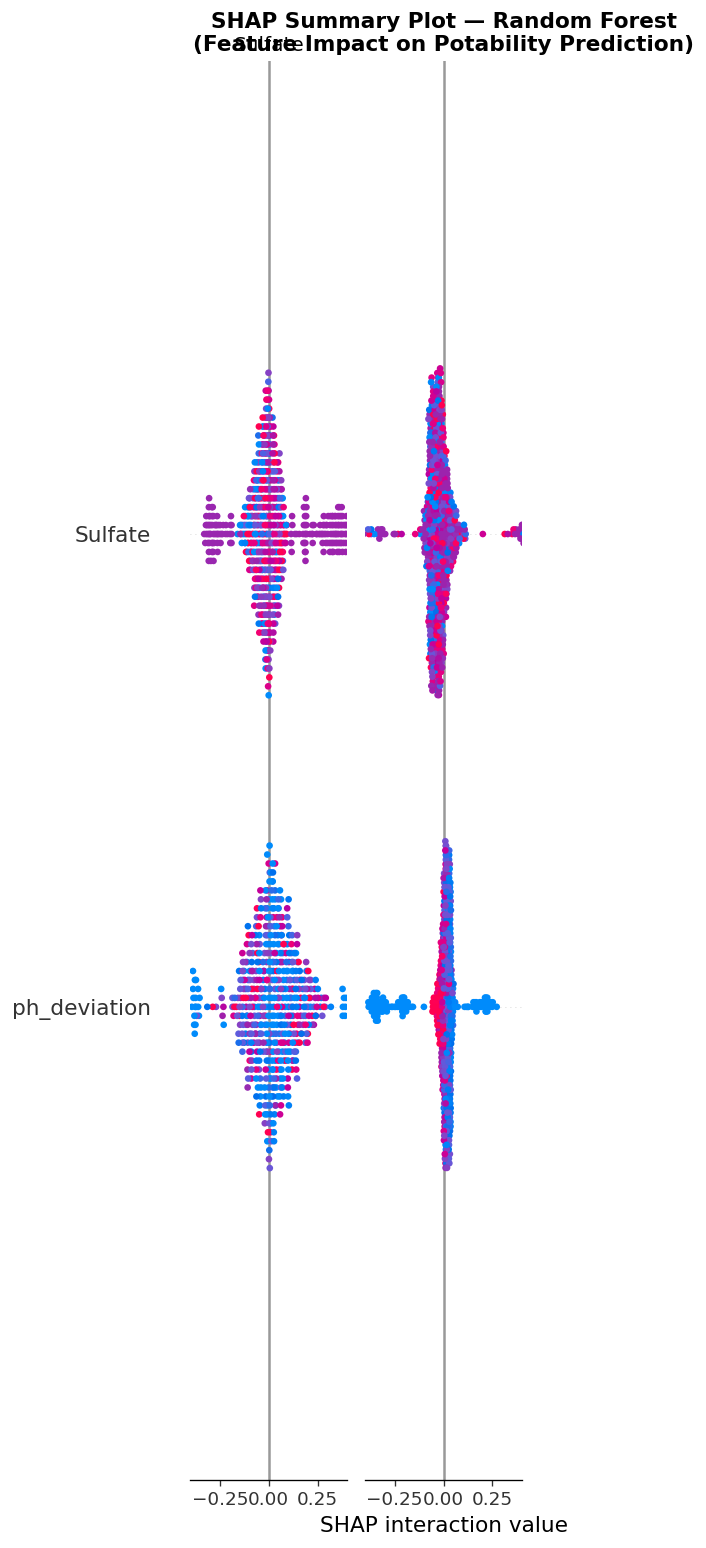


How to read this plot:
  • Each dot = one water sample
  • X-axis = SHAP value (impact on prediction)
  • Color = feature value (red=high, blue=low)
  • Features sorted by total impact (top = most important)



In [3]:
plt.figure(figsize=(10, 8))
shap.summary_plot(rf_shap_class1, X_test, show=False, max_display=15)
plt.title('SHAP Summary Plot — Random Forest\n(Feature Impact on Potability Prediction)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/shap_summary_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()

print("""
How to read this plot:
  • Each dot = one water sample
  • X-axis = SHAP value (impact on prediction)
  • Color = feature value (red=high, blue=low)
  • Features sorted by total impact (top = most important)
""")

## 8.3 Global Explanation — SHAP Bar Plot (Mean |SHAP|)

<Figure size 1200x840 with 0 Axes>

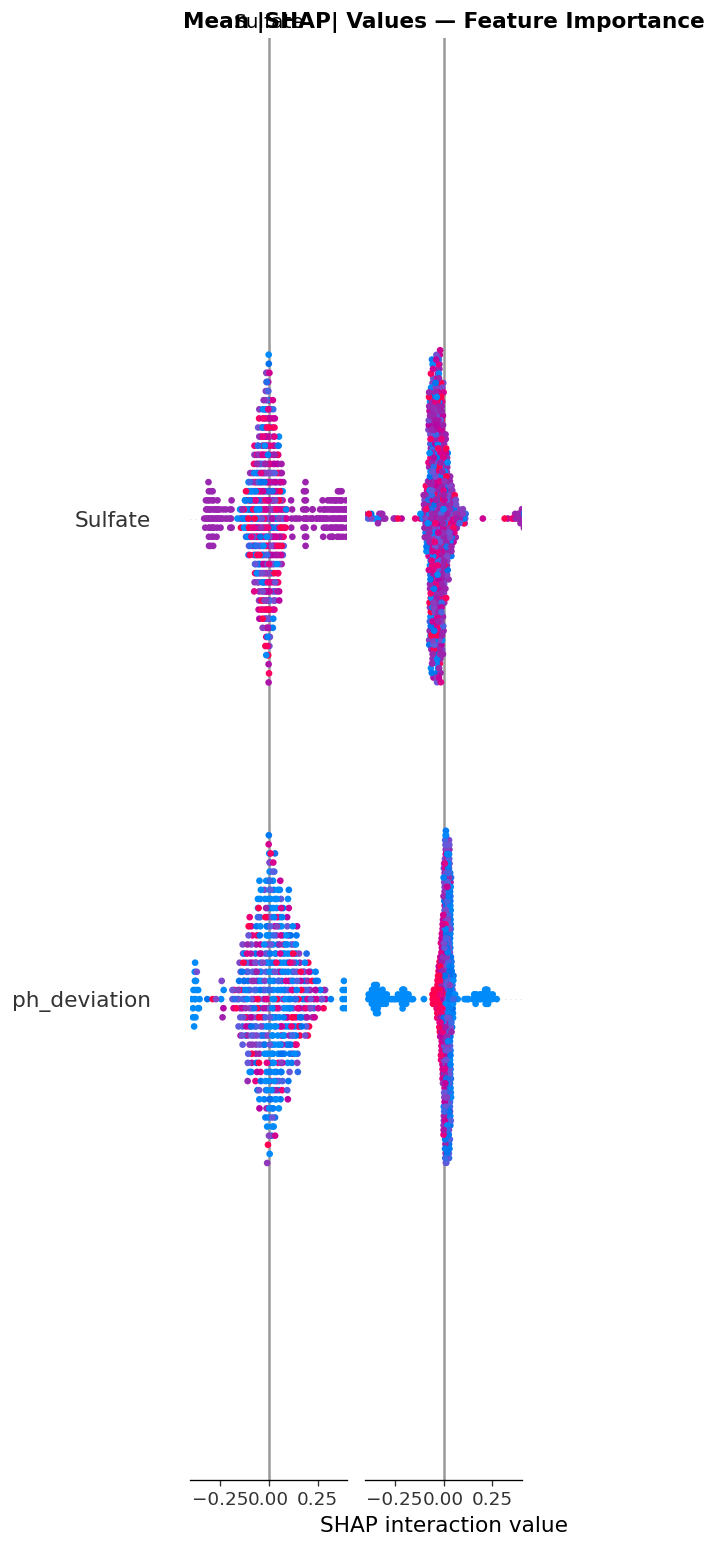

In [4]:
plt.figure(figsize=(10, 7))
shap.summary_plot(rf_shap_class1, X_test, plot_type='bar', show=False, max_display=15)
plt.title('Mean |SHAP| Values — Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/shap_bar_importance.png', bbox_inches='tight', dpi=150)
plt.show()

## 8.4 Local Explanation — Waterfall Plot (Single Prediction)

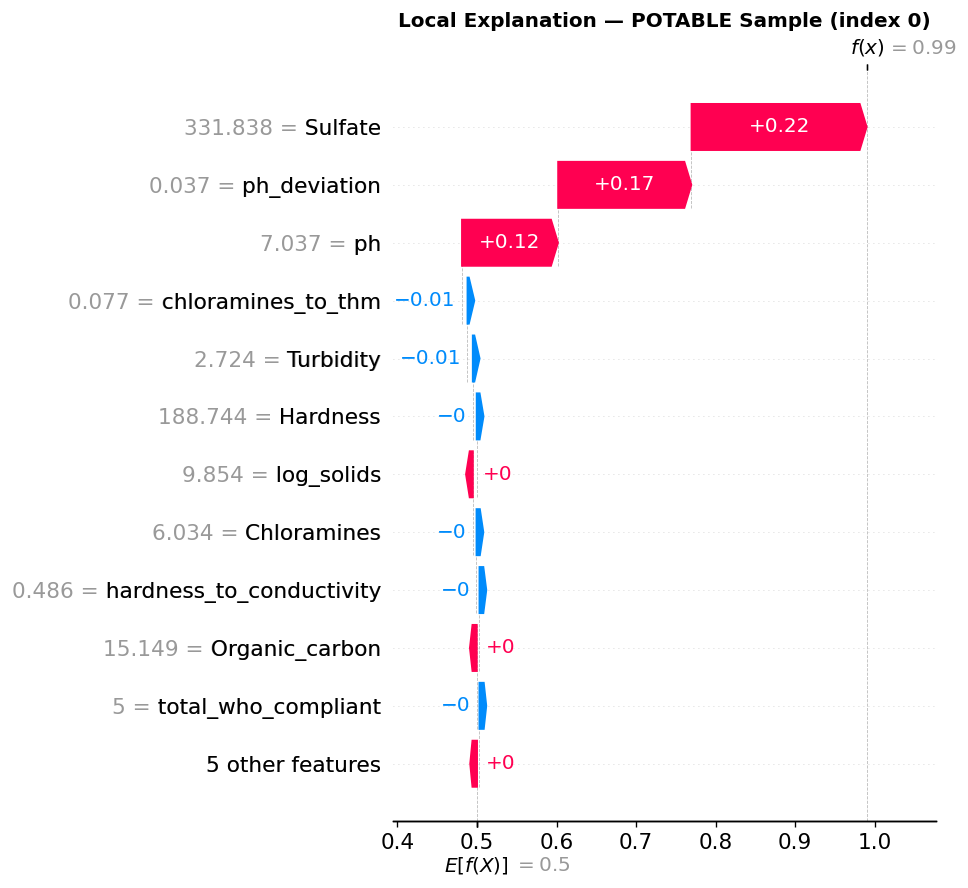

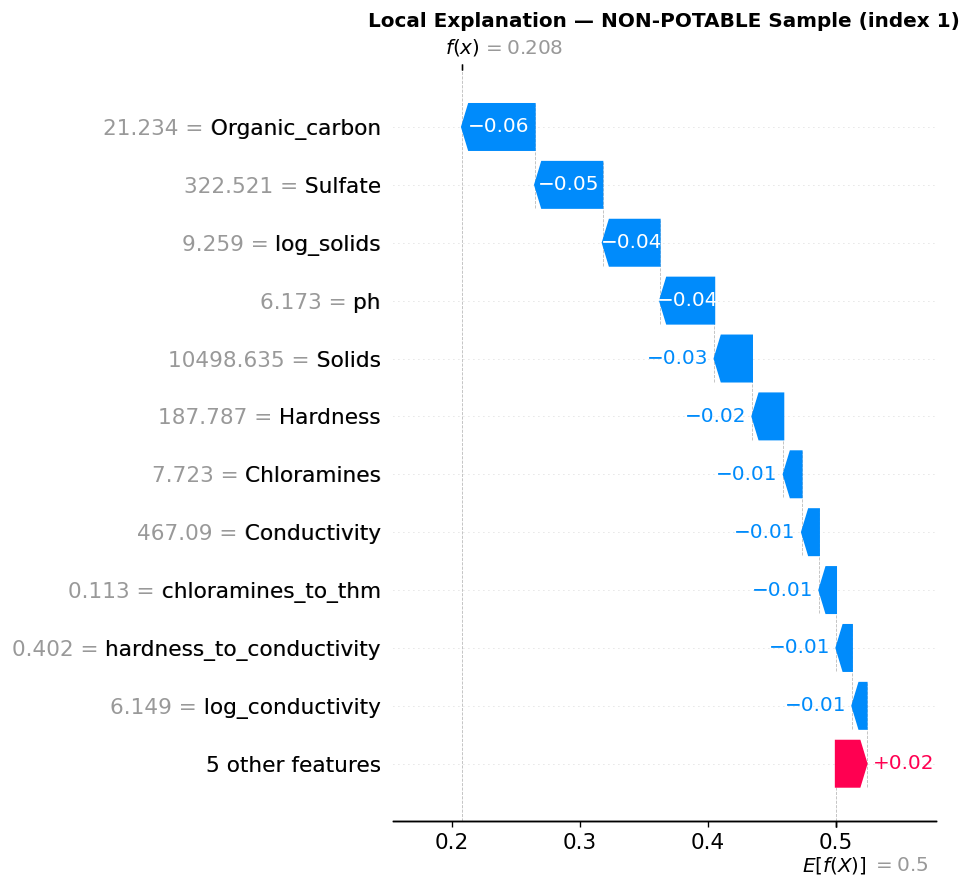

In [5]:
# Pick one potable sample and one non-potable sample for local explanation
potable_idx     = y_test[y_test == 1].index[0]
nonpotable_idx  = y_test[y_test == 0].index[0]

# Reindex to 0-based for SHAP
test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

potable_pos    = y_test_reset[y_test_reset == 1].index[0]
nonpotable_pos = y_test_reset[y_test_reset == 0].index[0]

# SHAP Explanation object
rf_explainer2 = shap.TreeExplainer(best_rf)
shap_exp = rf_explainer2(test_reset)

# Potable sample waterfall
fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.waterfall(shap_exp[potable_pos, :, 1], show=False, max_display=12)
plt.title(f'Local Explanation — POTABLE Sample (index {potable_pos})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/shap_waterfall_potable.png', bbox_inches='tight', dpi=150)
plt.show()

# Non-potable sample waterfall
fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.waterfall(shap_exp[nonpotable_pos, :, 1], show=False, max_display=12)
plt.title(f'Local Explanation — NON-POTABLE Sample (index {nonpotable_pos})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/shap_waterfall_nonpotable.png', bbox_inches='tight', dpi=150)
plt.show()

## 8.5 SHAP Dependence Plots — Top 3 Features

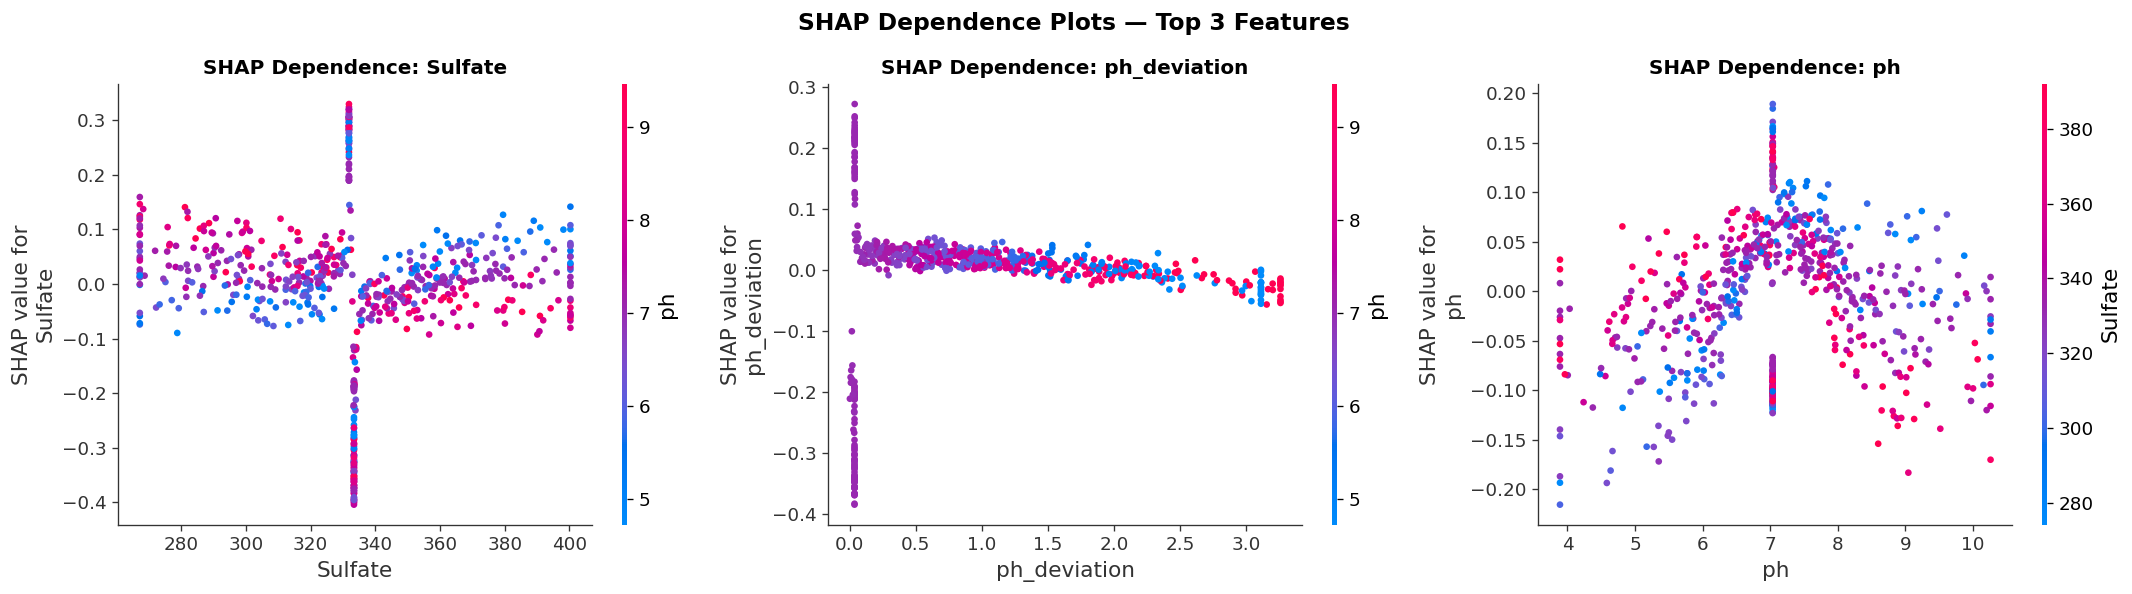

In [6]:
# Use the SHAP values in 2D format for dependence plots
# Extract class 1 (Potable) SHAP values from the Explanation object
expected_shap = shap_exp.values[:, :, 1]  # Shape: (n_samples, n_features)

# Get top 3 features by mean |SHAP|
mean_shap = np.abs(expected_shap).mean(axis=0)
top3_idx = np.argsort(mean_shap)[::-1][:3]
top3_features = [X_test.columns[i] for i in top3_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top3_features):
    shap.dependence_plot(feat, expected_shap, test_reset, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {feat}', fontweight='bold')

plt.suptitle('SHAP Dependence Plots — Top 3 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/shap_dependence_plots.png', bbox_inches='tight', dpi=150)
plt.show()

## 8.6 Environmental Monitoring Insights

In [7]:
mean_shap_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean |SHAP|': mean_shap
}).sort_values('Mean |SHAP|', ascending=False)

print('=== ACTIONABLE INSIGHTS FOR ENVIRONMENTAL MONITORING ===')
print()
print('Top features driving potability prediction:')
for _, row in mean_shap_df.head(5).iterrows():
    print(f'  {row["Feature"]:<25} SHAP impact: {row["Mean |SHAP|"]:.4f}')

print()
print('Monitoring Recommendations:')
print('  1. Prioritize pH and Sulfate testing — highest SHAP impact')
print('  2. WHO compliance score (total_who_compliant) is a strong predictor')
print('  3. Chloramine levels critically affect safety predictions')
print('  4. High Organic Carbon combined with high Turbidity → high non-potable risk')
print('  5. pH deviation from 7.0 > 1.0 strongly correlates with non-potability')

=== ACTIONABLE INSIGHTS FOR ENVIRONMENTAL MONITORING ===

Top features driving potability prediction:
  Sulfate                   SHAP impact: 0.1044
  ph_deviation              SHAP impact: 0.0624
  ph                        SHAP impact: 0.0598
  Solids                    SHAP impact: 0.0137
  Hardness                  SHAP impact: 0.0129

Monitoring Recommendations:
  1. Prioritize pH and Sulfate testing — highest SHAP impact
  2. WHO compliance score (total_who_compliant) is a strong predictor
  3. Chloramine levels critically affect safety predictions
  4. High Organic Carbon combined with high Turbidity → high non-potable risk
  5. pH deviation from 7.0 > 1.0 strongly correlates with non-potability
